# [LAB-11] 6. [연습문제] 서울 월평균 기온의 평활

> **문제**
>
> `temperatures_seoul` 데이터는 1973년 7월 ~ 2023년 8월까지 서울의 월평균 기온이다.
> 계절 요동이 지배적이어서 원본 그래프로는 장기 변화를 읽을 수 없다.
> 평활로 계절 요동을 걷어내고 **장기 추세를 드러내시오.**
>
> 1. 창 크기 **3 · 6 · 12 · 24** 를 비교해 **어떤 창을 써야 하는지와 이유**를 답하시오.
> 2. **이동평균과 지수평활** 중 적합한 것을 고르고 **이유**를 답하시오.
> 3. 평활로 드러난 **50년간의 기온 변화**를 답하시오.

## #01. 준비작업

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


In [2]:
origin = load_data('temperatures_seoul')

# freq="MS" 로 매월 1일 간격임을 명시해야 창 크기 12가 "1년"을 뜻하게 된다
df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m} | {len(df)}개월 | 간격 {df.index.freqstr}")
df.head(3)

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
기간: 1973-07 ~ 2023-08 | 602개월 | 간격 MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323


## #02. 원본 확인

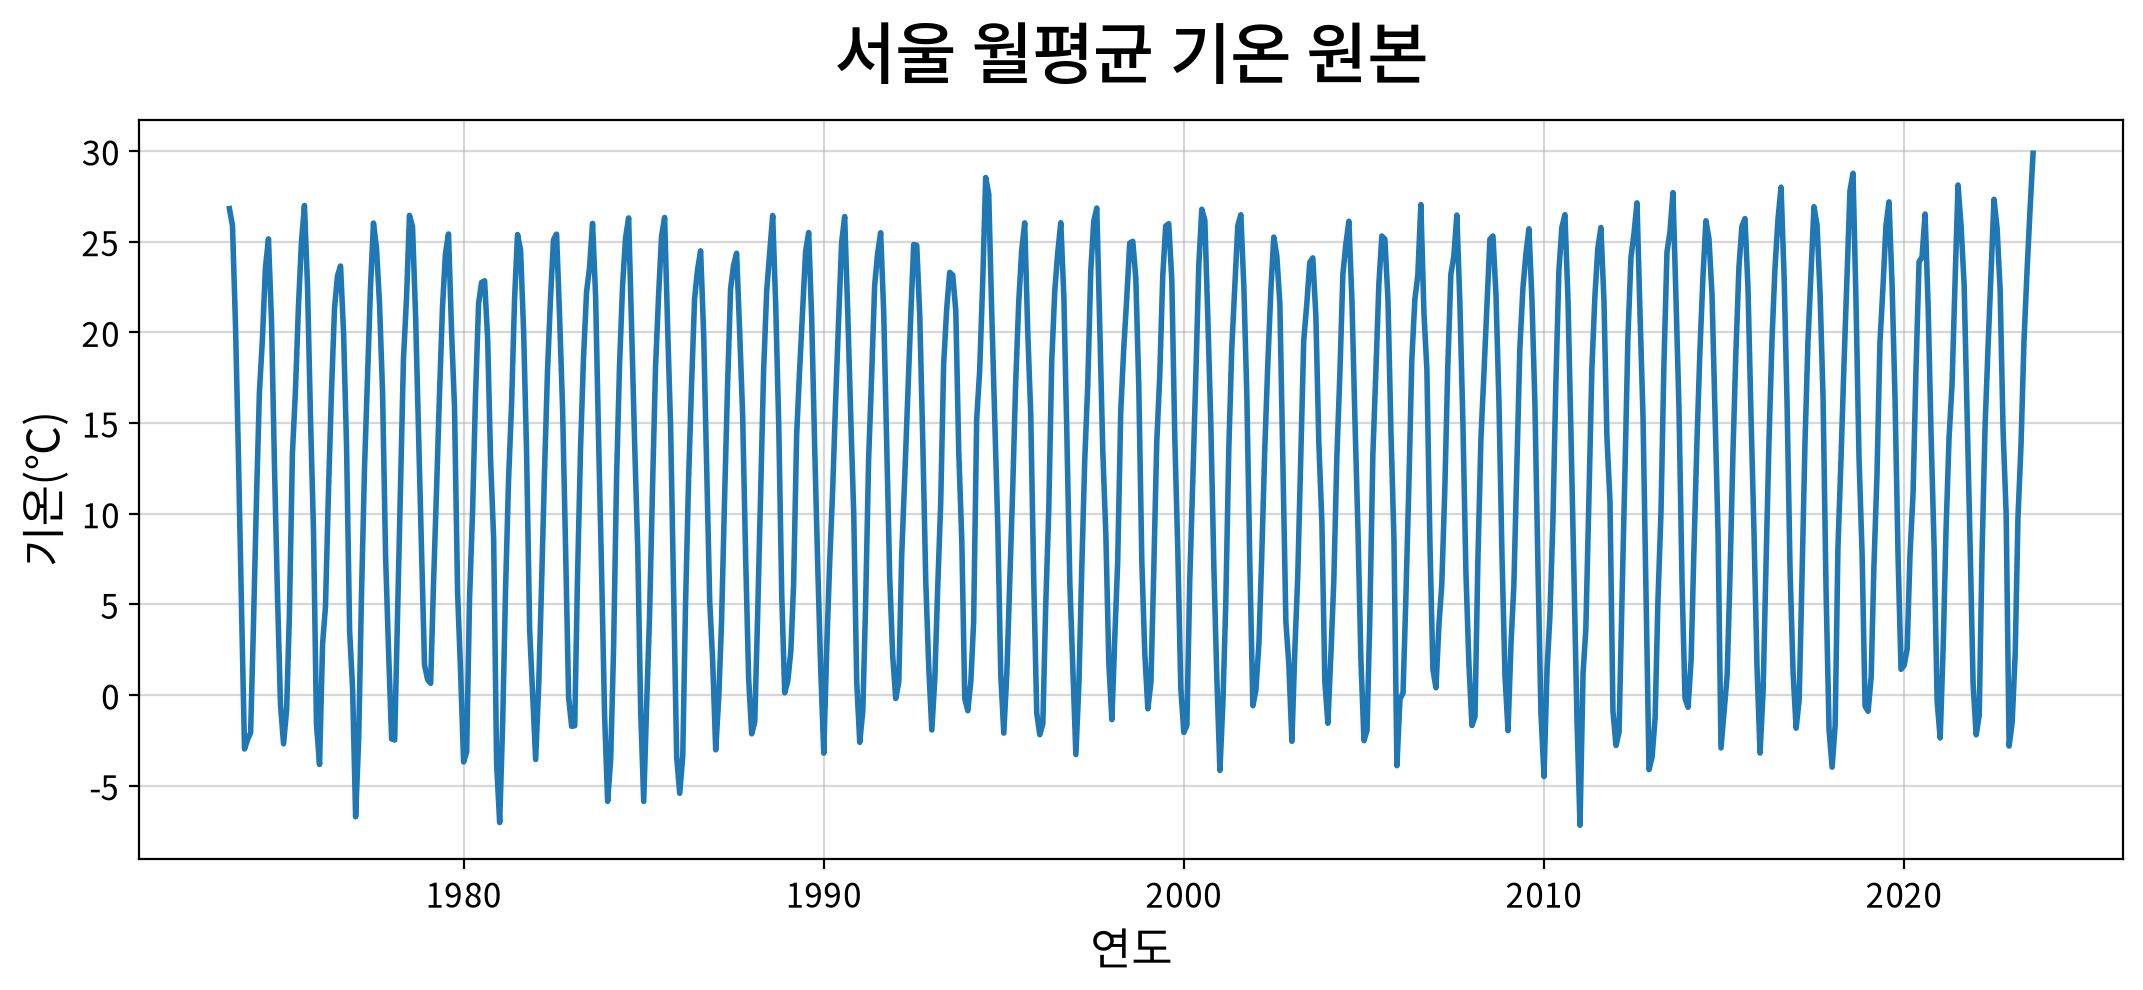

In [3]:
my_plot.lineplot(data=df, x=df.index, y="평균기온(℃)",
                 title="서울 월평균 기온 원본",
                 xlabel="연도", ylabel="기온(℃)",
                 width=1280, height=480)

매년 **−7℃ ~ +30℃** 를 오르내리는 요동이 반복된다. 이 크기에 묻혀 **장기 변화가 보이지 않는다.**

## #03. 창 크기 비교

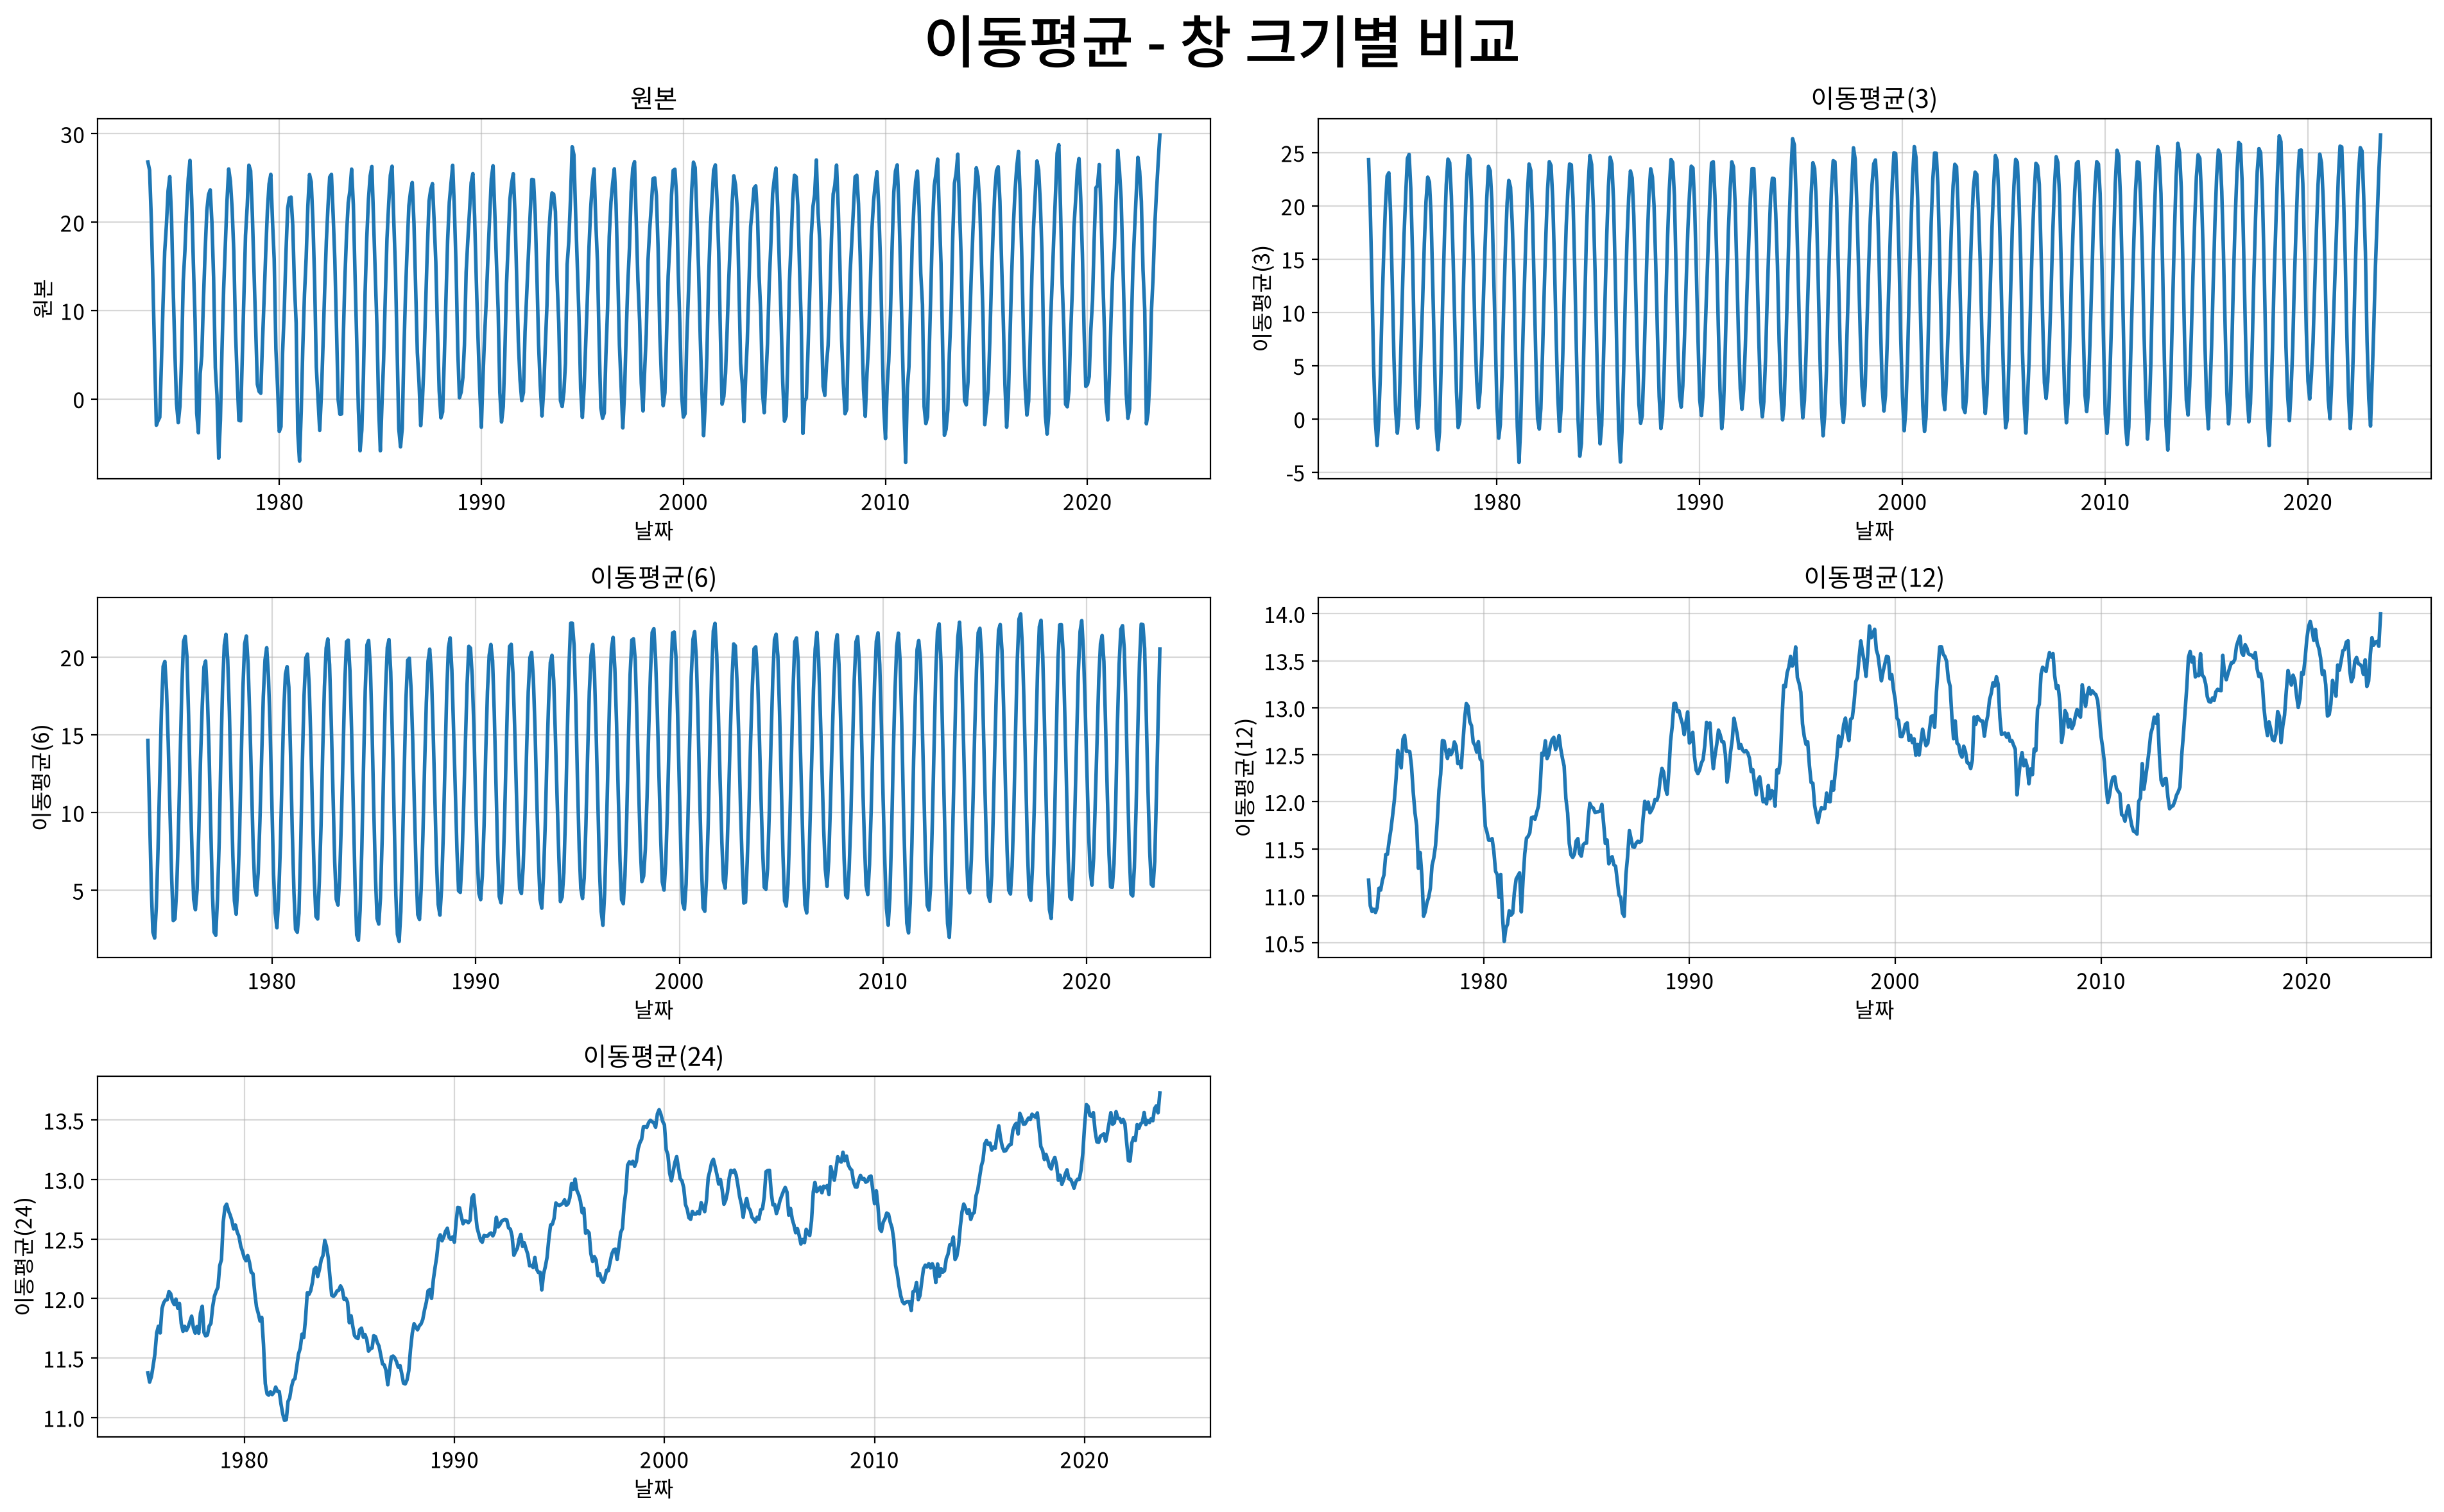

In [4]:
ma = my_ts.compare_smoothing(df, (3, 6, 12, 24), "평균기온(℃)", method="ma",
                             title="이동평균 - 창 크기별 비교",
                             width=960, height=400)

In [5]:
# 반환된 표의 각 열이 얼마나 평평해졌는지 표준편차로 잰다
ma.std().round(3).to_frame("표준편차")

,표준편차
원본,9.932
이동평균(3),8.970
이동평균(6),6.332
이동평균(12),0.745
이동평균(24),0.627


#### 💡 인사이트

| 창 | 표준편차 | 원본 대비 |
|---|---|---|
| 원본 | 9.932 | 100% |
| 3 | 8.970 | 90.3% |
| 6 | 6.332 | 63.8% |
| **12** | **0.745** | **7.5%** |
| 24 | 0.627 | 6.3% |

★ **창을 계절 주기와 같게(12) 잡아야 여름 +15℃와 겨울 −15℃가 상쇄된다.**
창 6은 반년치만 섞이므로 63.8%가 그대로 남는다.

창 12에서 남은 7.5%는 계절성이 아니라 **찾던 장기 추세**다.
창 24도 계절성은 지우지만 양 끝 결측이 늘어난다 → **가장 작은 창**을 쓴다.

## #04. 이동평균 vs 지수평활

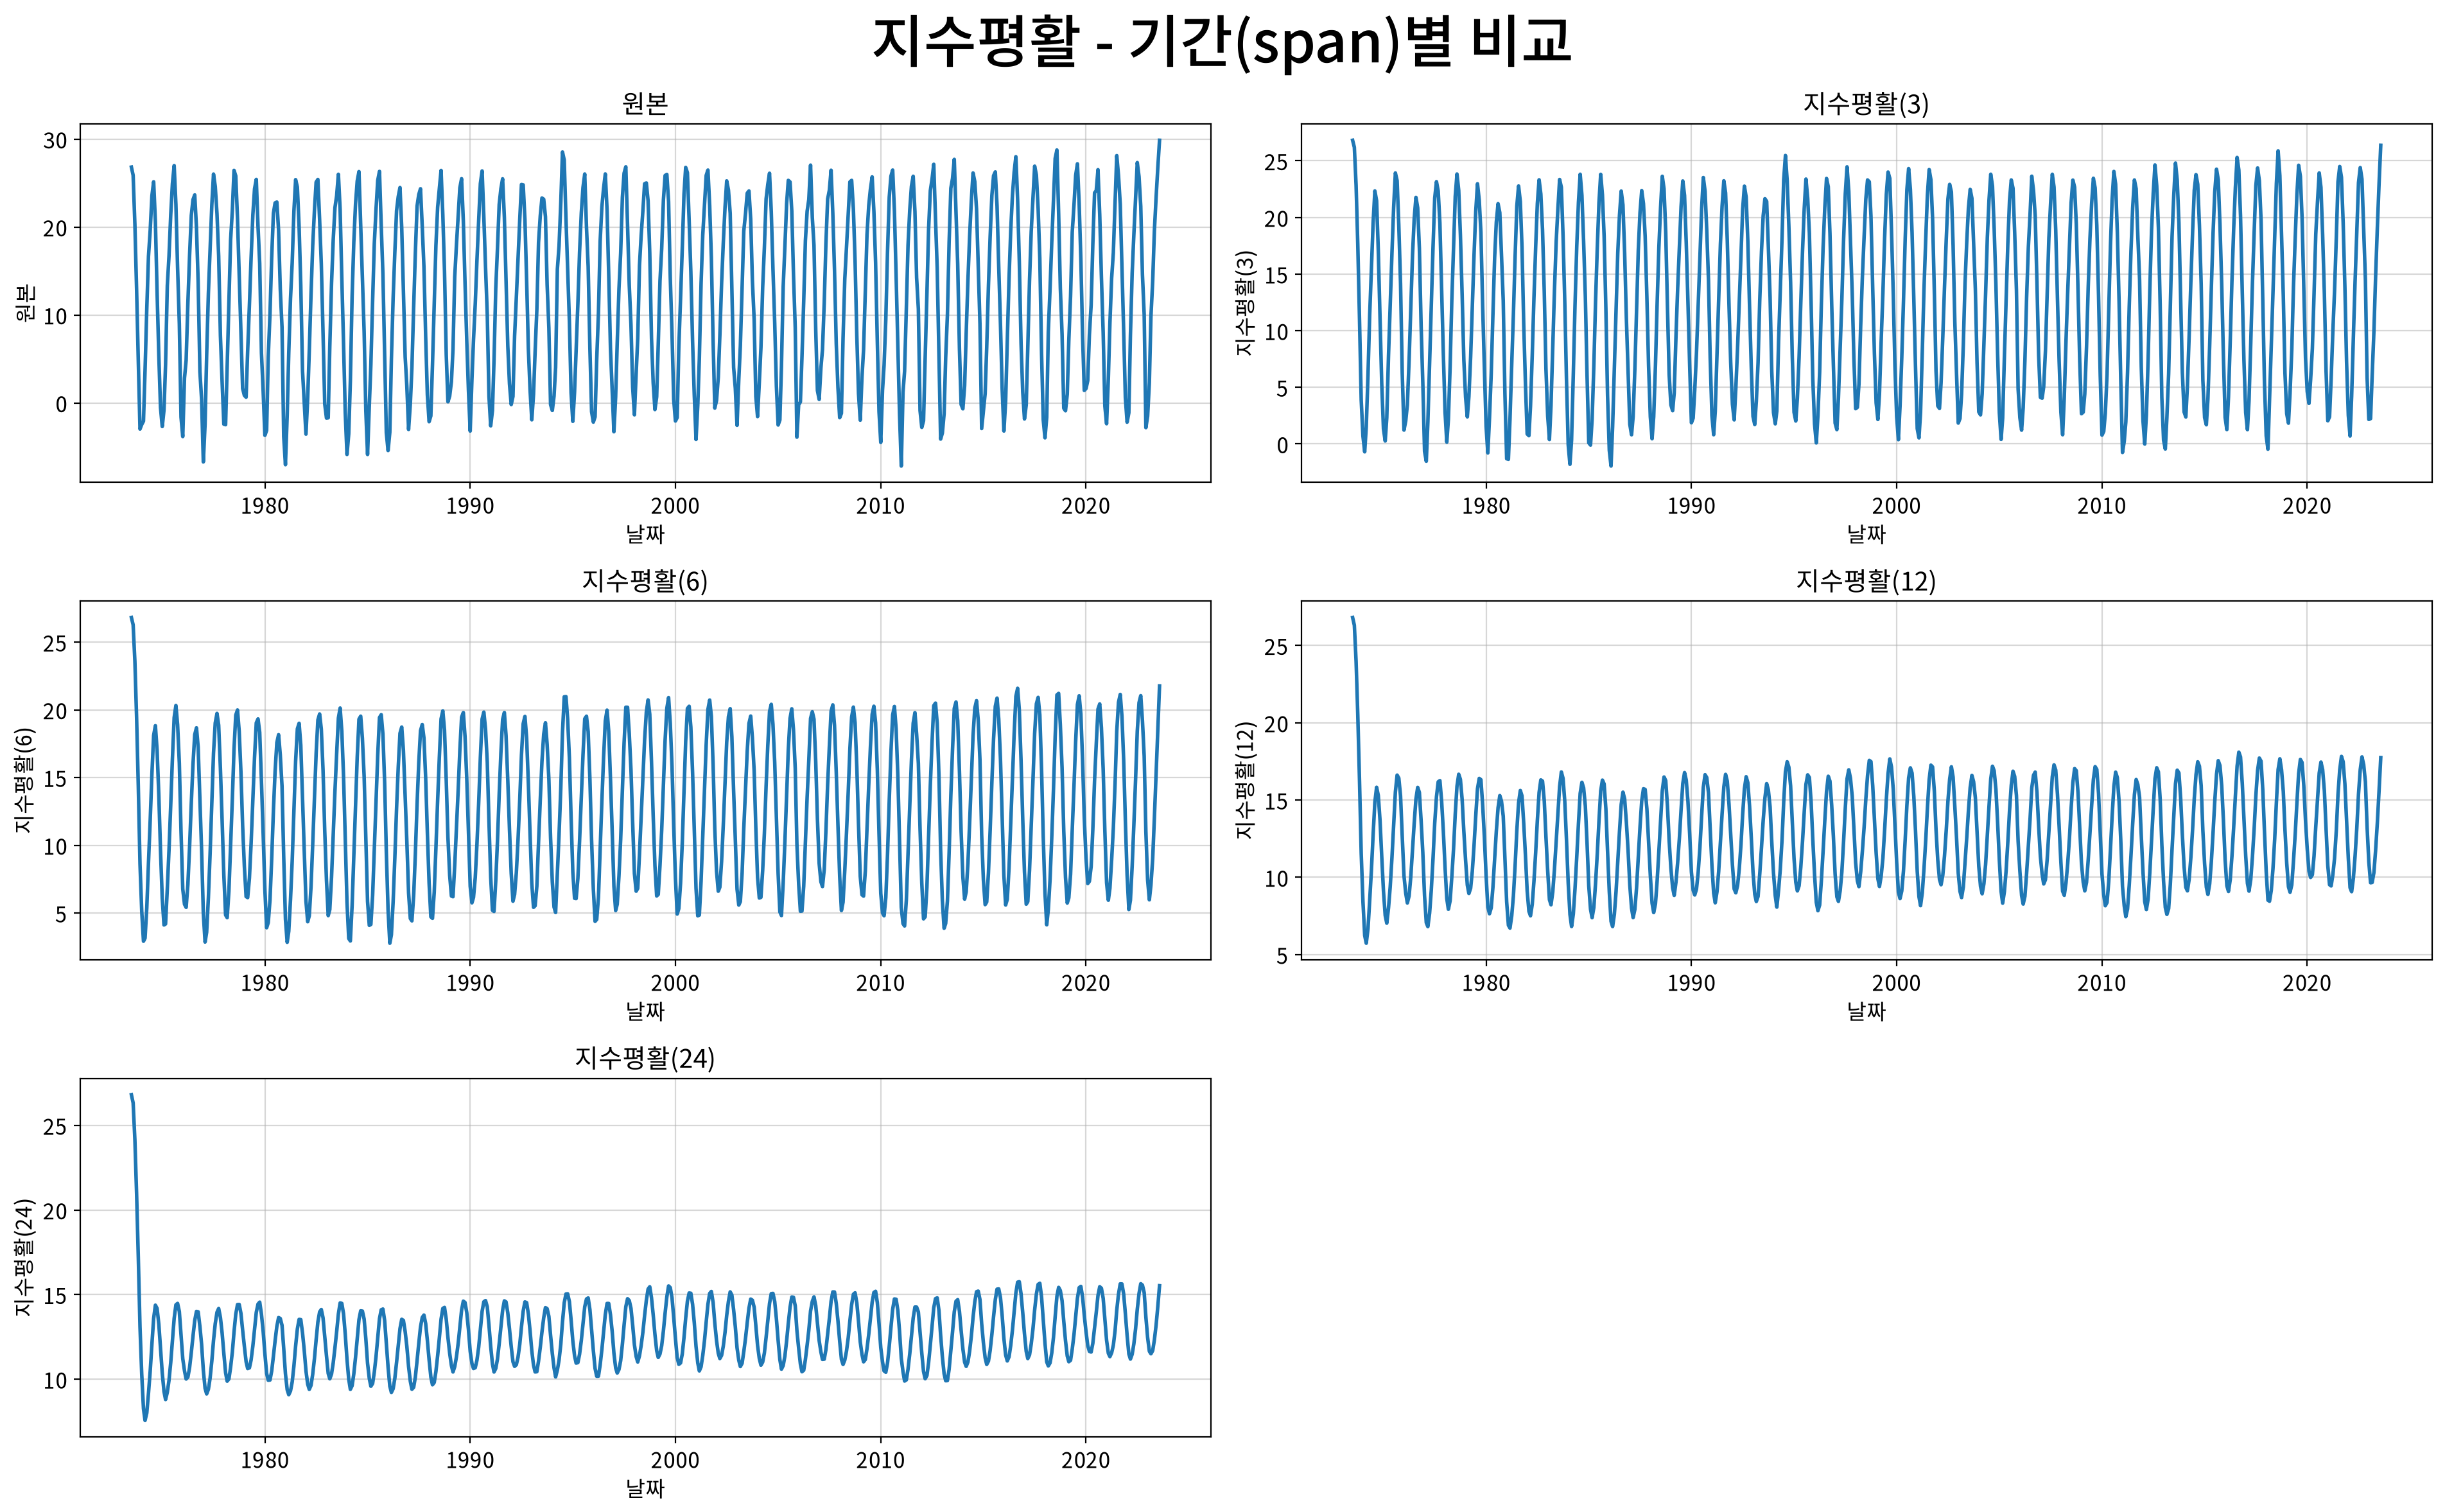

,표준편차
원본,9.932
지수평활(3),7.991
지수평활(6),5.483
지수평활(12),3.251
지수평활(24),1.983


In [6]:
ew = my_ts.compare_smoothing(df, (3, 6, 12, 24), "평균기온(℃)", method="ewm",
                             title="지수평활 - 기간(span)별 비교",
                             width=960, height=400)

ew.std().round(3).to_frame("표준편차")

#### 💡 인사이트

| 기간 | 이동평균 | 지수평활 |
|---|---|---|
| 3 | 8.970 | 7.991 |
| 6 | 6.332 | 5.483 |
| **12** | **0.745** | **3.251** |
| 24 | 0.627 | 1.983 |

기간 3·6에서는 지수평활이 더 매끄럽지만 **12에서 순위가 뒤집힌다.**

★ **지수평활은 최근 값에 큰 가중치를 주므로 현재 계절 쪽으로 끌려간다.**
이동평균은 12개월을 똑같은 비중으로 평균 내므로 계절이 정확히 상쇄된다.

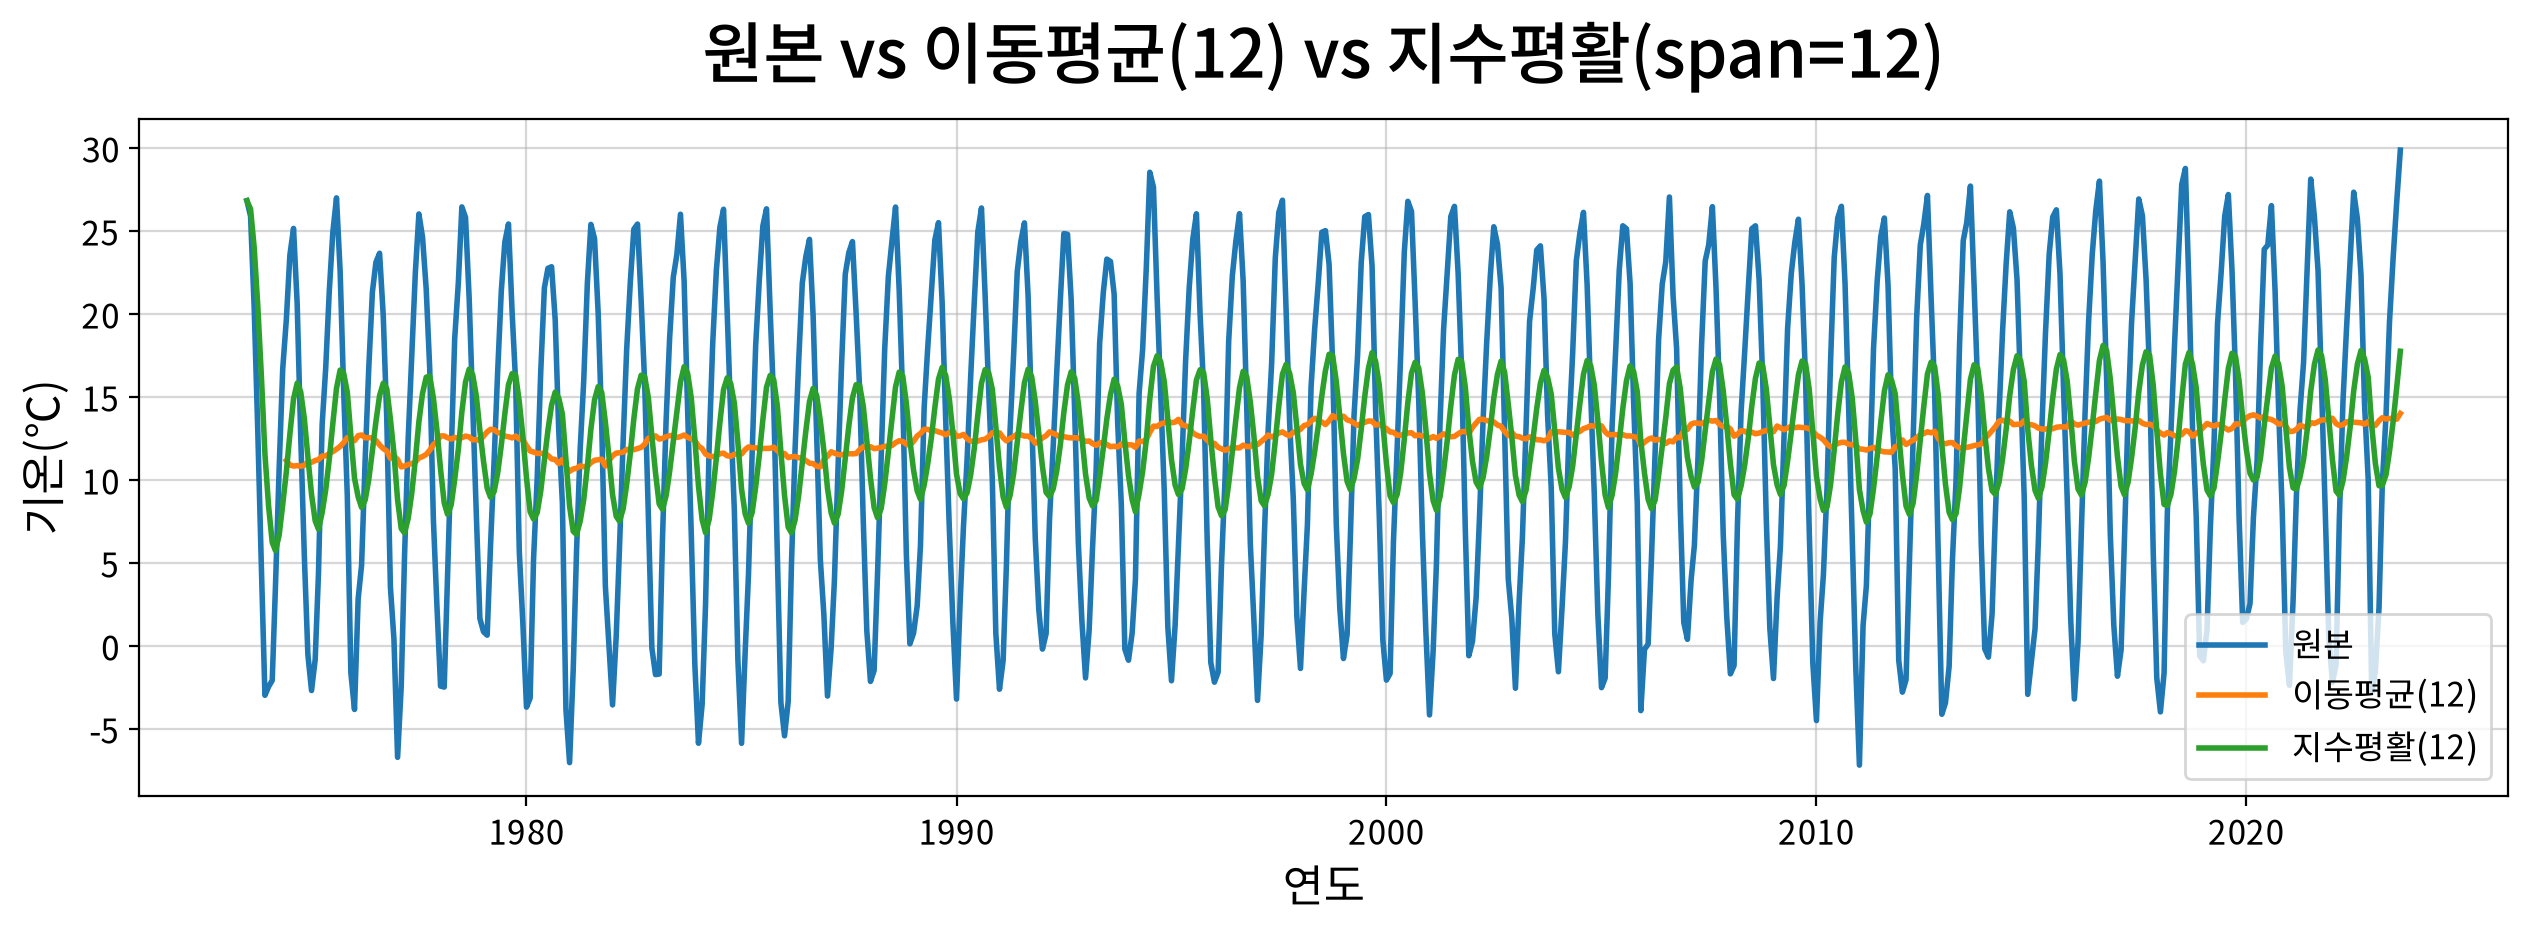

,원본,이동평균(12),지수평활(12)
날짜,,,
2023-06-01,23.383,13.706,13.516
2023-07-01,26.706,13.654,15.545
2023-08-01,29.867,13.997,17.748


In [7]:
both = my_ts.compare_smoothing(df, [12], "평균기온(℃)", method="both", overlay=True,
                               title="원본 vs 이동평균(12) vs 지수평활(span=12)",
                               xlabel="연도", ylabel="기온(℃)",
                               width=1280, height=480)

both.tail(3)

이동평균은 톱니가 사라진 완만한 곡선, 지수평활은 여전히 출렁이며 원본을 뒤쫓는다.

## #05. 최종 확인

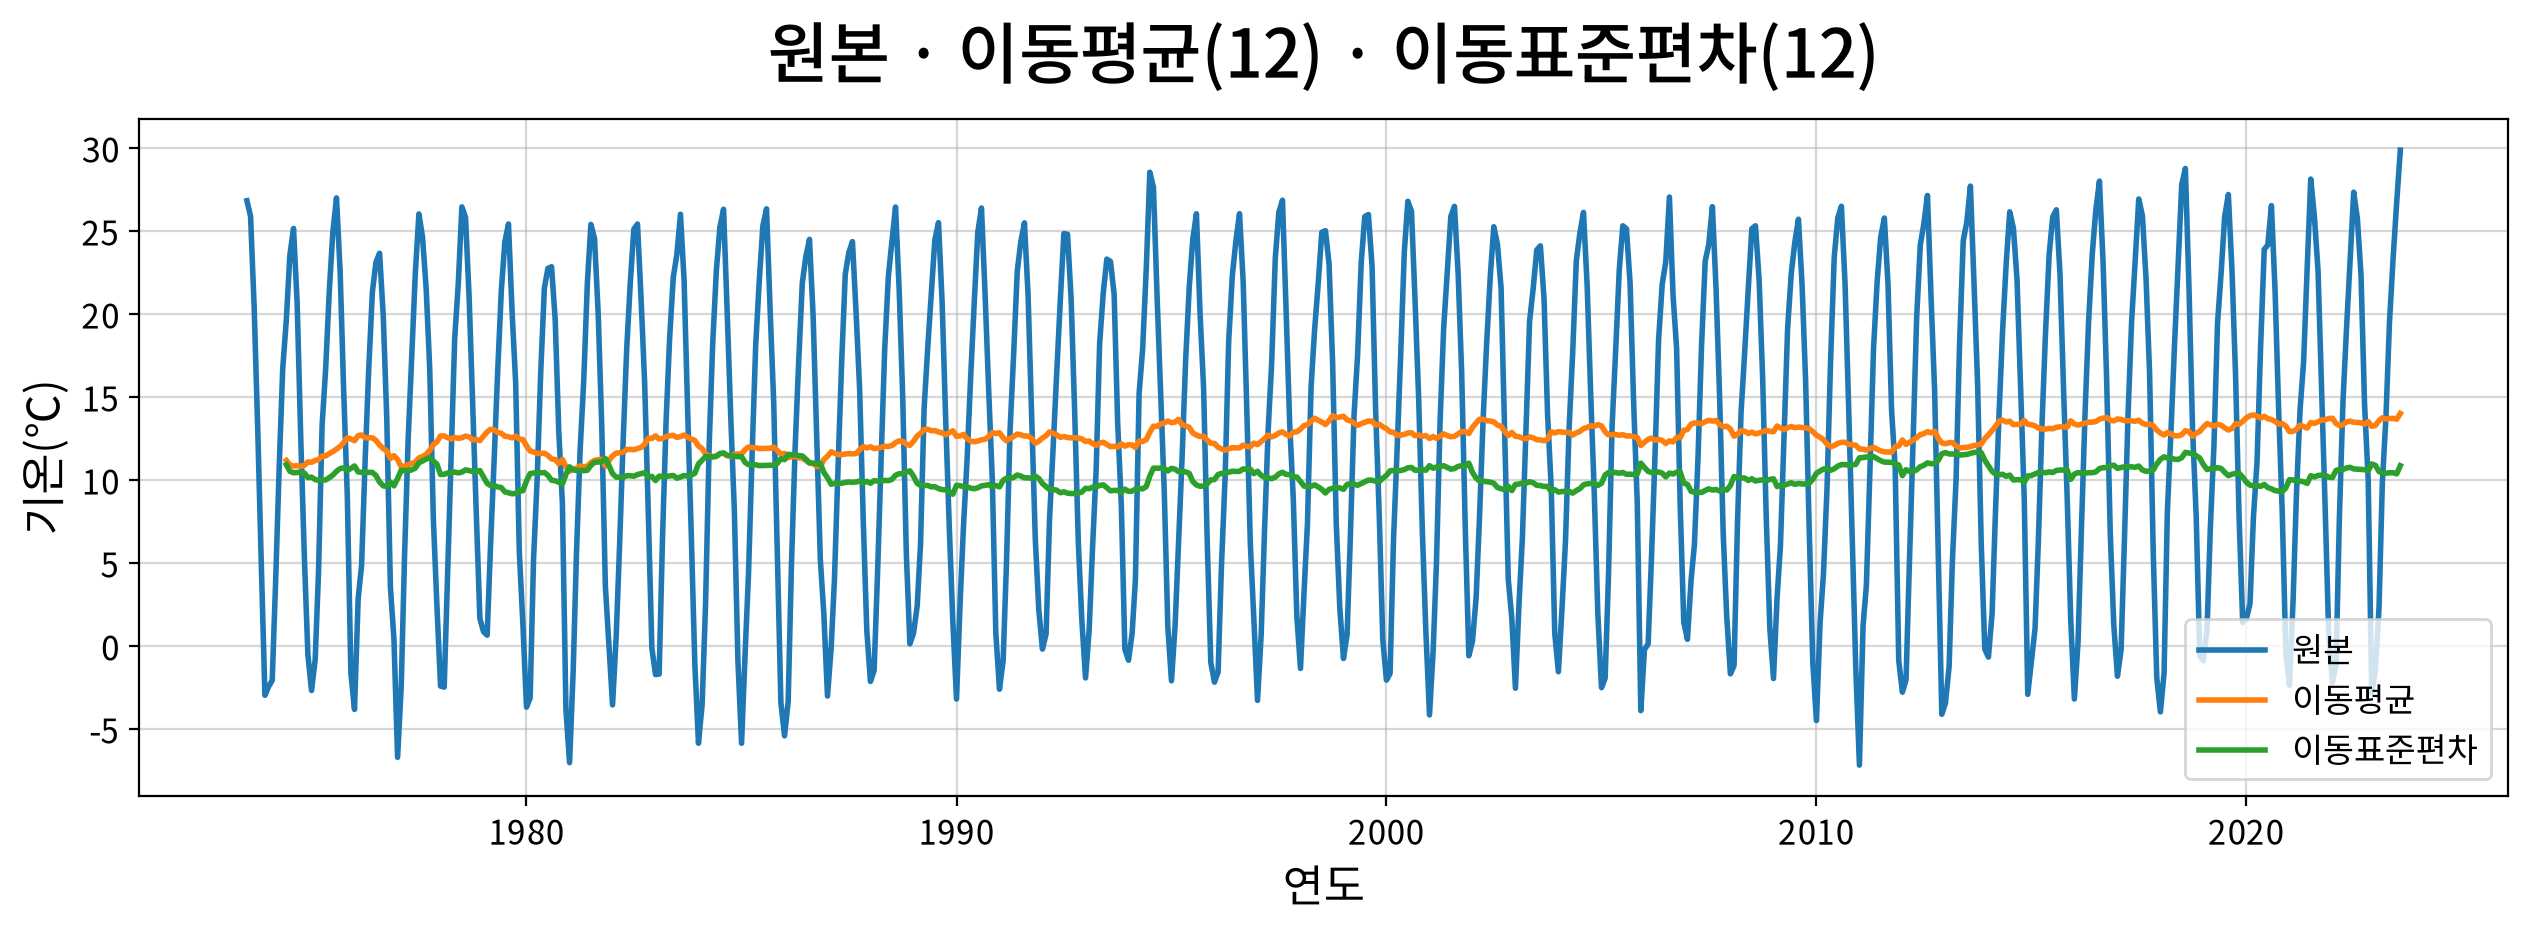

,원본,이동평균,이동표준편차
count,602.000,591.000,591.000
mean,12.614,12.562,10.285
std,9.932,0.745,0.604
min,-7.184,10.515,9.137
25%,3.558,12.053,9.791
50%,13.816,12.637,10.327
75%,21.865,13.167,10.669
max,29.867,13.997,11.667


In [8]:
rolling = my_ts.plot_rolling(df, 12, "평균기온(℃)",
                             title="원본 · 이동평균(12) · 이동표준편차(12)",
                             xlabel="연도", ylabel="기온(℃)",
                             width=1280, height=480)

rolling.describe().round(3)

In [9]:
trend = rolling["이동평균"].dropna()

print(f"시작 {trend.index[0]:%Y-%m}  {trend.iloc[0]:.3f}℃")
print(f"최종 {trend.index[-1]:%Y-%m}  {trend.iloc[-1]:.3f}℃")
print(f"변화 {trend.iloc[-1] - trend.iloc[0]:+.3f}℃")

시작 1974-06  11.168℃
최종 2023-08  13.997℃
변화 +2.830℃


#### 💡 인사이트

원본에서 전혀 보이지 않던 **+2.830℃ 상승**이 드러났다.
이동표준편차가 평평하므로 변동폭은 일정하다 → **로그변환 불필요.**

## #06. 정답

### 1번 — 창 크기 **12**

계절 주기와 같게 잡아야 여름과 겨울이 상쇄되어 계절성이 지워진다.
표준편차 **9.932 → 0.745 (7.5%)**. 창 6은 63.8%가 남아 절반도 못 지운다.
창 24도 지워지지만 결측이 늘어나므로 **가장 작은 창**을 쓴다.

### 2번 — **이동평균**

같은 기간 12에서 **이동평균 0.745 vs 지수평활 3.251 — 4.4배 차이.**
지수평활은 최근 값 가중 때문에 계절의 흔적이 남는다.

> 우열이 아니라 목적의 문제다.
> 장기 추세 → **이동평균(창 = 주기)** / 현재 상태·단기 예측 → **지수평활**

### 3번 — 약 **+2.83℃**

1974-06 **11.168℃** → 2023-08 **13.997℃**

### 반드시 기억할 것

| 원칙 | 내용 |
|---|---|
| 🔑 창 크기는 계절 주기로 | 주기의 배수가 아니면 계절성이 크게 남는다 |
| 🔑 목적이 방법을 정한다 | 장기 추세 → 이동평균 / 현재 상태 → 지수평활 |
| 🔑 가장 작은 창을 쓴다 | 창이 넓을수록 결측이 늘고 최근 변화에 둔해진다 |
| 🔑 평활은 EDA다 | "2.8℃ 상승"은 눈으로 확인한 것이지 검정된 결론이 아니다 |